# Waste Classification with CNN
Notebook ini mencakup seluruh proses dari awal hingga akhir:
1. **Training Model**
2. **Plot Hasil Training (Akurasi & Loss)**
3. **Evaluasi (Confusion Matrix & Classification Report)**
4. **Prediksi Gambar Baru**

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2026-06-20 11:09:28.383864: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-20 11:09:28.945371: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-20 11:09:28.945488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-20 11:09:29.087394: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-20 11:09:29.395456: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-20 11:09:32.175861: W tensorflow/compiler/tf2tensorrt/utils/py_utils.

## 1. Persiapan Data (Data Generators)

In [2]:
dataset_path = 'archive (3)/TrashType_Image_Dataset'

# Gunakan Data Augmentation HANYA untuk data training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Data validasi tidak boleh diaugmentasi, cukup di-rescale saja
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42, # Gunakan seed yang sama agar split-nya konsisten
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False # PENTING: Harus False agar urutan sesuai saat evaluasi Confusion Matrix
)

class_names = list(train_data.class_indices.keys())
print("\nKelas yang dideteksi:", class_names)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.

Kelas yang dideteksi: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 2. Membuat Arsitektur CNN dan Training
*Jika Anda sudah memiliki model yang di-training, Anda bisa melewati block code untuk `.fit` dan cukup meload modelnya menggunakan `load_model`.*

In [3]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       


2026-06-20 11:09:39.006246: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29491200 exceeds 10% of free system memory.
2026-06-20 11:09:39.061874: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29491200 exceeds 10% of free system memory.
2026-06-20 11:09:39.096274: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29491200 exceeds 10% of free system memory.


                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 57600)             0         
                                                                 
 dense (Dense)               (None, 128)               7372928   
                                                                 
 dense_1 (Dense)             (None, 6)                 774       
                                                                 
Total para

In [4]:
print("Mulai proses training...")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

model.save('trash_classifier_model.h5')
print("Model berhasil disimpan!")

Mulai proses training...
Epoch 1/10


2026-06-20 11:09:40.659235: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29491200 exceeds 10% of free system memory.
2026-06-20 11:09:40.672715: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29491200 exceeds 10% of free system memory.


64/64 [==============================] - 87s 1s/step - loss: 1.7656 - accuracy: 0.3009 - val_loss: 1.3510 - val_accuracy: 0.4632
Epoch 2/10
64/64 [==============================] - 69s 1s/step - loss: 1.3652 - accuracy: 0.4580 - val_loss: 1.3259 - val_accuracy: 0.4573
Epoch 3/10
64/64 [==============================] - 67s 1s/step - loss: 1.2493 - accuracy: 0.4965 - val_loss: 1.2576 - val_accuracy: 0.5328
Epoch 4/10
64/64 [==============================] - 77s 1s/step - loss: 1.1709 - accuracy: 0.5371 - val_loss: 1.2219 - val_accuracy: 0.5726
Epoch 5/10
64/64 [==============================] - 77s 1s/step - loss: 1.1224 - accuracy: 0.5618 - val_loss: 1.2623 - val_accuracy: 0.5686
Epoch 6/10
64/64 [==============================] - 72s 1s/step - loss: 1.0460 - accuracy: 0.6077 - val_loss: 1.2085 - val_accuracy: 0.5586
Epoch 7/10
64/64 [==============================] - 70s 1s/step - loss: 1.0554 - accuracy: 0.6047 - val_loss: 1.1032 - val_accuracy: 0.6083
Epoch 8/10
64/64 [=============

## 3. Visualisasi Hasil Training

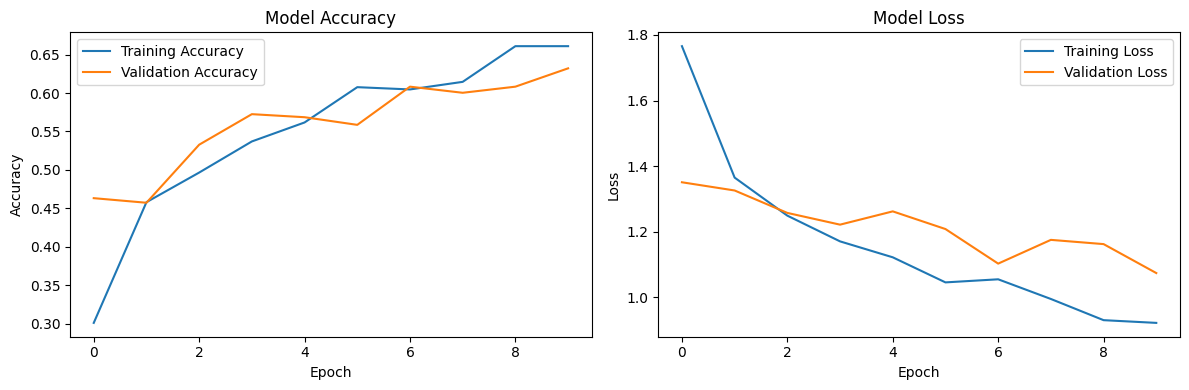

In [5]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Evaluasi Model (Confusion Matrix & Classification Report)

Melakukan prediksi pada data validasi...
16/16 [==============================] - 5s 267ms/step

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.90      0.75      0.82        80
       glass       0.61      0.52      0.56       100
       metal       0.49      0.57      0.53        82
       paper       0.63      0.85      0.72       118
     plastic       0.62      0.56      0.59        96
       trash       0.50      0.19      0.27        27

    accuracy                           0.63       503
   macro avg       0.63      0.57      0.58       503
weighted avg       0.64      0.63      0.62       503



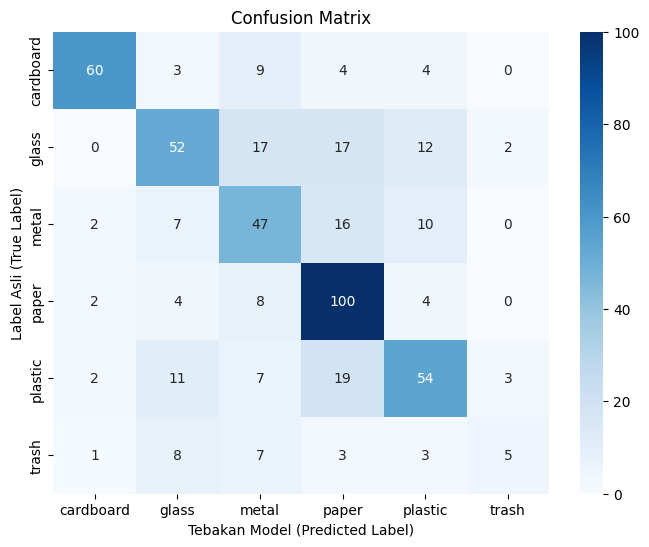

In [6]:
# Lakukan prediksi pada data validasi
print("Melakukan prediksi pada data validasi...")
Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

# Label asli
y_true = val_data.classes

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Tebakan Model (Predicted Label)')
plt.show()

## 5. Prediksi Gambar Baru
Di bawah ini adalah fungsi untuk menebak sebuah gambar. Ganti `sample_img_path` dengan path gambar yang Anda inginkan.


Mengetes prediksi pada file: archive (3)/TrashType_Image_Dataset/metal/metal_254.jpg
1/1 [==============================] - 1s 590ms/step


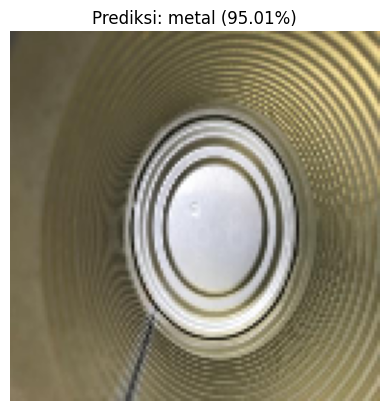

In [7]:
def predict_image(image_path, model):
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)
    predicted_class_idx = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100
    
    predicted_label = class_names[predicted_class_idx]
    
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Prediksi: {predicted_label} ({confidence:.2f}%)')
    plt.show()

# Pilih sembarang gambar dari folder dataset untuk dites secara otomatis
import glob
import random

test_images = glob.glob(f'{dataset_path}/*/*.*')
if test_images:
    sample_img_path = random.choice(test_images)
    print(f"\nMengetes prediksi pada file: {sample_img_path}")
    predict_image(sample_img_path, model)